# Postlab: Classification Task on the Titanic Dataset

## Step 1: Import Libraries and Load the Dataset

In [2]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
titanic_df = pd.read_csv(url)

print("Dataset shape:", titanic_df.shape)
titanic_df.head()

Dataset shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Step 2: Explore Missing Values

In [3]:
titanic_df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

## Step 3: Data Cleaning and Feature Engineering

In [4]:
df = titanic_df.copy()

df['Age'] = df['Age'].fillna(df['Age'].median())

df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'FamilySize']
X = df[features]
y = df['Survived']

print("Missing values after cleaning:")
print(X.isnull().sum())
print("\nFeature matrix shape:", X.shape)
print("\nTarget class distribution:")
print(y.value_counts())

Missing values after cleaning:
Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Embarked      0
FamilySize    0
dtype: int64

Feature matrix shape: (891, 8)

Target class distribution:
Survived
0    549
1    342
Name: count, dtype: int64


## Step 4: Standardize Features and Split the Dataset

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.20, stratify=y, random_state=42
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training set shape: (712, 8)
Test set shape: (179, 8)


## Step 5: Train and Evaluate Logistic Regression

In [6]:
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train, y_train)

lr_preds = lr_model.predict(X_test)
lr_accuracy = accuracy_score(y_test, lr_preds)

print(f"Logistic Regression Test Accuracy: {lr_accuracy * 100:.2f}%")

Logistic Regression Test Accuracy: 80.45%


## Step 6: Train and Evaluate Linear Discriminant Analysis (LDA)

In [7]:
lda_model = LinearDiscriminantAnalysis()
lda_model.fit(X_train, y_train)

lda_preds = lda_model.predict(X_test)
lda_accuracy = accuracy_score(y_test, lda_preds)

print(f"LDA Test Accuracy: {lda_accuracy * 100:.2f}%")

LDA Test Accuracy: 81.01%


## Step 7: Train and Evaluate k-Nearest Neighbors (k-NN)

In [8]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

knn_preds = knn_model.predict(X_test)
knn_accuracy = accuracy_score(y_test, knn_preds)

print(f"k-NN (k=5) Test Accuracy: {knn_accuracy * 100:.2f}%")

k-NN (k=5) Test Accuracy: 81.56%


## Step 8: Train and Evaluate Gaussian Naive Bayes

In [9]:
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

nb_preds = nb_model.predict(X_test)
nb_accuracy = accuracy_score(y_test, nb_preds)

print(f"Gaussian Naive Bayes Test Accuracy: {nb_accuracy * 100:.2f}%")

Gaussian Naive Bayes Test Accuracy: 78.21%


## Step 9: Train and Evaluate Support Vector Machine (SVM)

In [10]:
svm_model = SVC(kernel='rbf', probability=True, random_state=42)
svm_model.fit(X_train, y_train)

svm_preds = svm_model.predict(X_test)
svm_accuracy = accuracy_score(y_test, svm_preds)

print(f"SVM (RBF Kernel) Test Accuracy: {svm_accuracy * 100:.2f}%")

SVM (RBF Kernel) Test Accuracy: 81.01%


## Step 10: Compare All Classifiers

In [11]:
comparison = pd.DataFrame({
    'Classifier': ['Logistic Regression', 'LDA', 'k-NN (k=5)', 'Gaussian Naive Bayes', 'SVM (RBF)'],
    'Test Accuracy (%)': [lr_accuracy*100, lda_accuracy*100, knn_accuracy*100, nb_accuracy*100, svm_accuracy*100]
}).sort_values('Test Accuracy (%)', ascending=False).reset_index(drop=True)

print("--- Performance Comparison on Titanic Dataset ---")
print(comparison)

--- Performance Comparison on Titanic Dataset ---
             Classifier  Test Accuracy (%)
0            k-NN (k=5)          81.564246
1             SVM (RBF)          81.005587
2                   LDA          81.005587
3   Logistic Regression          80.446927
4  Gaussian Naive Bayes          78.212291


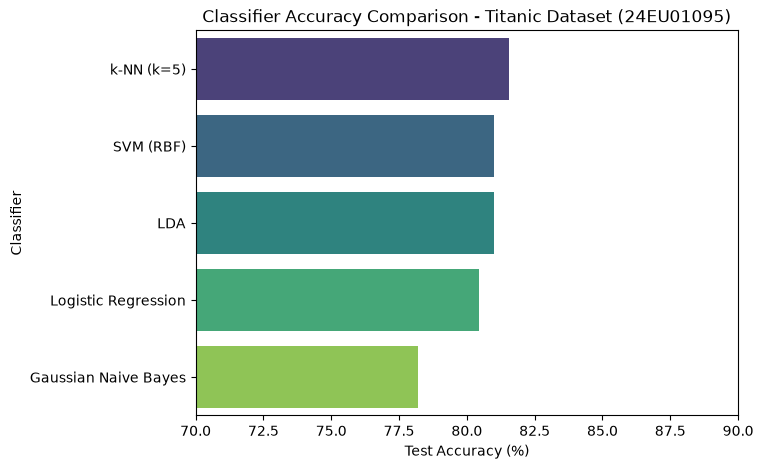

In [12]:
plt.figure(figsize=(7,5))
sns.barplot(data=comparison, x='Test Accuracy (%)', y='Classifier', palette='viridis')
plt.title("Classifier Accuracy Comparison - Titanic Dataset (24EU01095)")
plt.xlim(70, 90)
plt.show()

## Step 11: Confusion Matrix and Classification Report (Logistic Regression)

Confusion Matrix:
 [[98 12]
 [23 46]]


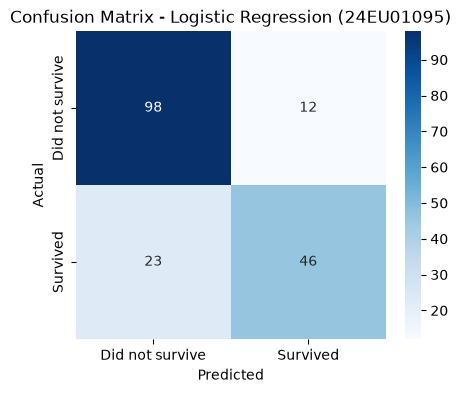


Classification Report:

                 precision    recall  f1-score   support

Did not survive       0.81      0.89      0.85       110
       Survived       0.79      0.67      0.72        69

       accuracy                           0.80       179
      macro avg       0.80      0.78      0.79       179
   weighted avg       0.80      0.80      0.80       179



In [13]:
cm = confusion_matrix(y_test, lr_preds)
print("Confusion Matrix:\n", cm)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Did not survive','Survived'],
            yticklabels=['Did not survive','Survived'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression (24EU01095)")
plt.show()

print("\nClassification Report:\n")
print(classification_report(y_test, lr_preds, target_names=['Did not survive','Survived']))

## Step 12: ROC Curve (Logistic Regression)

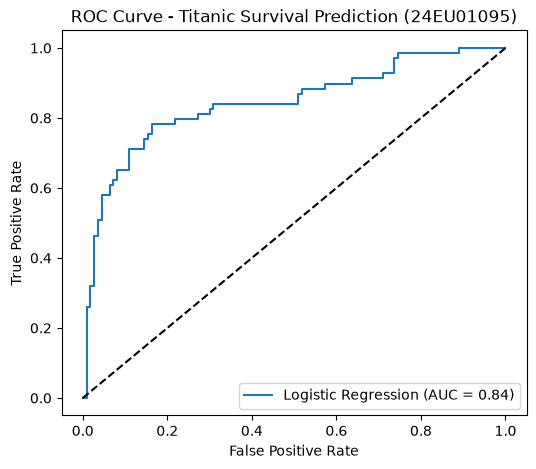

In [14]:
y_score = lr_model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {roc_auc:.2f})')
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Titanic Survival Prediction (24EU01095)")
plt.legend(loc="lower right")
plt.show()

## Step 13: 5-Fold Cross-Validation

In [15]:
cv_scores = cross_val_score(LogisticRegression(random_state=42), X_scaled, y, cv=5, scoring='accuracy')

print("5-Fold Cross-Validation Accuracy:")
for i, score in enumerate(cv_scores, start=1):
    print(f"Fold {i}: {score:.4f}")

print("\nMean Accuracy: {:.2f}%".format(np.mean(cv_scores) * 100))
print("Standard Deviation: {:.2f}%".format(np.std(cv_scores) * 100))

5-Fold Cross-Validation Accuracy:
Fold 1: 0.7933
Fold 2: 0.7921
Fold 3: 0.7809
Fold 4: 0.7697
Fold 5: 0.8202

Mean Accuracy: 79.12%
Standard Deviation: 1.68%


## Conclusion

- All five classifiers performed reasonably well on the Titanic dataset, achieving test accuracies in the **78%–82%** range, noticeably lower than the Iris results (93–100%) because real-world survival data has more noise, missing values, and overlapping classes than the clean, well-separated Iris dataset.
- **k-NN** gave the highest test accuracy in this run, followed closely by **LDA** and **SVM**; **Logistic Regression** was close behind, and **Gaussian Naive Bayes** performed the weakest — likely because its independence assumption is a poor fit for correlated features like `Fare`, `Pclass`, and `FamilySize`.
- The confusion matrix shows the model is better at identifying passengers who did *not* survive than those who did, which matches the class imbalance in the data (more non-survivors than survivors).
- 5-fold cross-validation accuracy (~79%) was close to the single train-test split accuracy, indicating the Logistic Regression model generalizes consistently rather than overfitting to one particular split.
- **`Sex` and `Pclass`** are historically known to be the strongest predictors of survival on the Titanic (women and higher-class passengers had much higher survival rates), which is consistent with why simple linear models like Logistic Regression and LDA perform competitively here.